# Huang et al. (2025) 再現（有限データ M 版, simple）

このノートブックは `paper_reproduce.ipynb` の有限データ版（簡略化）です。

- 学習データは最初に `M` タスク固定で生成
- 学習中は毎回新規サンプルせず、固定データからミニバッチ抽出
- 評価は新規タスクで実施（汎化性能）
- 設定は `w0=random` + `no_cot` のみ（他モードは削除）


In [212]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# ===== 実験設定（simple: w0=random, no_cot 固定） =====
D = 20
N = 200
TRAIN_TASKS_M = 4000  # 固定学習データ数 M
BATCH_SIZE = 100
ADAM_LR = 1e-3
PARAM_L2_LAMBDA = 0.1
ITERATIONS = 2000
EVAL_K_LIST = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]

SEED = 42
DE = 2 * D + 2

np.random.seed(SEED)
torch.manual_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(
    f"device={device}, d={D}, n={N}, M={TRAIN_TASKS_M}, B={BATCH_SIZE}, "
    f"iters={ITERATIONS}, w0=random, mode=no_cot, l2={PARAM_L2_LAMBDA}"
)


device=cpu, d=20, n=200, M=4000, B=100, iters=2000, w0=random, mode=no_cot, l2=0.1


In [213]:
def sample_task_batch(batch_size, d=D, n=N, device=device):
    X = torch.randn(batch_size, d, n, device=device)
    w_star = torch.randn(batch_size, d, device=device)
    y = torch.einsum("bd,bdn->bn", w_star, X)
    return X, y, w_star


def build_fixed_train_dataset(M=TRAIN_TASKS_M):
    X, y, w_star = sample_task_batch(M)
    return {"X": X, "y": y, "w_star": w_star, "M": M}


def sample_train_minibatch(train_data, batch_size=BATCH_SIZE):
    idx = torch.randint(0, train_data["M"], (batch_size,), device=device)
    X = train_data["X"][idx]
    y = train_data["y"][idx]
    w_star = train_data["w_star"][idx]
    return X, y, w_star


def sample_w0_random(batch_size, d=D, device=device):
    return torch.randn(batch_size, d, device=device)


def build_Z(X, y, w_prefix):
    B, d, n = X.shape
    i = len(w_prefix) - 1
    L = n + i + 1
    Z = torch.zeros(B, DE, L, device=X.device)
    Z[:, :d, :n] = X
    Z[:, d, :n] = y
    for t, w_t in enumerate(w_prefix):
        Z[:, d + 1 : d + 1 + d, n + t] = w_t
    Z[:, -1, :] = 1.0
    return Z


def f_lsa_last(Z, V, W, n=N):
    z_last = Z[:, :, -1]
    Wz = torch.einsum("ij,bj->bi", W, z_last)
    scores = torch.einsum("bjl,bj->bl", Z, Wz) / n
    weighted = torch.einsum("bjl,bl->bj", Z, scores)
    out_last = z_last + torch.einsum("ij,bj->bi", V, weighted)
    return out_last


def no_cot_train_loss(V, W, X, y, w_star):
    w0 = sample_w0_random(X.shape[0], D, X.device)
    Z0 = build_Z(X, y, [w0])
    pred = f_lsa_last(Z0, V, W)
    target = torch.zeros_like(pred)
    target[:, D + 1 : D + 1 + D] = w_star
    target[:, -1] = 1.0
    return 0.5 * ((pred - target) ** 2).sum(dim=1).mean()


def eval_loss(V, W, k_eval, batch_size=1000):
    # 評価は新規タスク（汎化）
    X, y, w_star = sample_task_batch(batch_size)
    with torch.no_grad():
        # 推論時の初期値は 0 固定: k=0 は attention 未適用の 0 ベクトル誤差
        w0 = torch.zeros(batch_size, D, device=device)
        w_prefix = [w0]

        # k_eval 回だけ attention を適用（k=1:1回, k=2:2回, ...）
        for _ in range(k_eval):
            Z = build_Z(X, y, w_prefix)
            pred = f_lsa_last(Z, V, W)
            w_hat = pred[:, D + 1 : D + 1 + D]
            w_prefix.append(w_hat)

        w_hat_final = w_prefix[-1]
        loss = ((w_hat_final - w_star) ** 2).mean(dim=1).mean().item()
    return loss


def parameter_l2_penalty(V, W):
    return V.pow(2).sum() + W.pow(2).sum()


In [214]:
# 固定学習データを作成
train_data = build_fixed_train_dataset(TRAIN_TASKS_M)
print(f"fixed train dataset built: M={train_data['M']}")


def train_model_no_cot_finite(train_data, iterations=ITERATIONS, log_every=20):
    V = nn.Parameter(0.01 * torch.randn(DE, DE, device=device))
    W = nn.Parameter(0.01 * torch.randn(DE, DE, device=device))
    opt = torch.optim.Adam([V, W], lr=ADAM_LR)
    eval_curve = []
    for t in range(iterations):
        X, y, w_star = sample_train_minibatch(train_data, BATCH_SIZE)
        data_loss = no_cot_train_loss(V, W, X, y, w_star)
        reg_loss = PARAM_L2_LAMBDA * parameter_l2_penalty(V, W)
        loss = data_loss + reg_loss
        opt.zero_grad(set_to_none=True)
        loss.backward()
        opt.step()
        if t % log_every == 0:
            eval_curve.append(eval_loss(V, W, k_eval=0))
    return V.detach(), W.detach(), np.array(eval_curve)


fixed train dataset built: M=4000


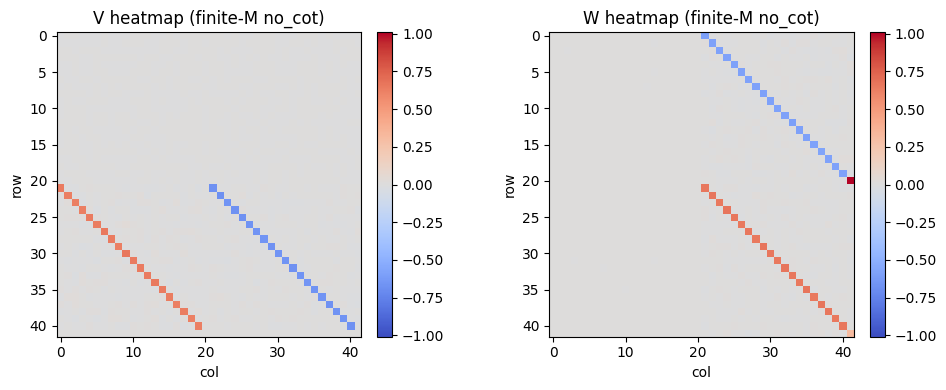

visualized model: finite-M no_cot
V shape=(42, 42), W shape=(42, 42)


In [215]:
# 学習後パラメータの可視化（no_cot 固定版）
if "V_tr" not in globals() or "W_tr" not in globals():
    raise ValueError("V_tr/W_tr が見つかりません。先に学習セルを実行してください。")

V_np = V_tr.detach().cpu().numpy()
W_np = W_tr.detach().cpu().numpy()

vmax = float(max(np.abs(V_np).max(), np.abs(W_np).max()))
vmax = max(vmax, 1e-8)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
im0 = axes[0].imshow(V_np, cmap="coolwarm", vmin=-vmax, vmax=vmax)
axes[0].set_title("V heatmap (finite-M no_cot)")
axes[0].set_xlabel("col")
axes[0].set_ylabel("row")
plt.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

im1 = axes[1].imshow(W_np, cmap="coolwarm", vmin=-vmax, vmax=vmax)
axes[1].set_title("W heatmap (finite-M no_cot)")
axes[1].set_xlabel("col")
axes[1].set_ylabel("row")
plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

print("visualized model: finite-M no_cot")
print(f"V shape={V_np.shape}, W shape={W_np.shape}")

In [216]:
# 学習実行（no_cot 固定）
print("training finite-M with no-CoT objective ...")
V_tr, W_tr, train_curve = train_model_no_cot_finite(train_data, iterations=ITERATIONS)

final_eval = {}
for k_eval in EVAL_K_LIST:
    final_eval[k_eval] = eval_loss(V_tr, W_tr, k_eval=k_eval)

result_label = f"finite-M no-CoT (M={TRAIN_TASKS_M})"

print("done")
for k_eval in sorted(final_eval.keys()):
    print(f"k_eval={k_eval:>2}: {final_eval[k_eval]:.6f}")


training finite-M with no-CoT objective ...
done
k_eval= 0: 0.996643
k_eval= 1: 0.096649
k_eval= 2: 0.028055
k_eval= 3: 0.031407
k_eval= 4: 0.038240
k_eval= 5: 0.043164
k_eval= 6: 0.046469
k_eval= 7: 0.048220
k_eval= 8: 0.049540
k_eval= 9: 0.050484
k_eval=10: 0.050885
k_eval=11: 0.051187
k_eval=12: 0.051398
k_eval=13: 0.051475
k_eval=14: 0.050838
k_eval=15: 0.051145


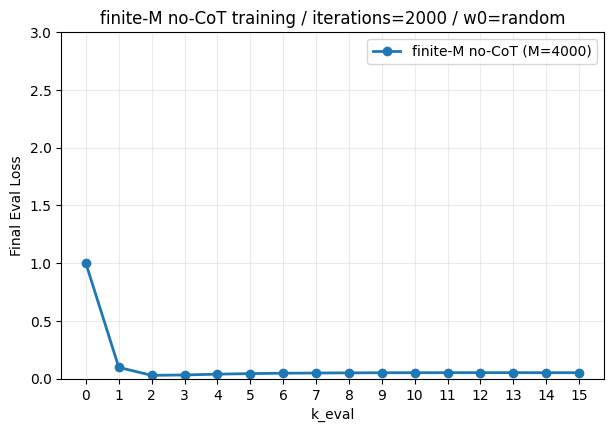

In [217]:
# 可視化
ks = np.array(sorted(final_eval.keys()))
vals = np.array([final_eval[k] for k in ks])

plt.figure(figsize=(7, 4.5))
plt.plot(ks, vals, marker="o", linewidth=2, label=result_label)
plt.xlabel("k_eval")
plt.ylabel("Final Eval Loss")
plt.title(f"finite-M no-CoT training / iterations={ITERATIONS} / w0=random")
plt.xticks(ks)
plt.ylim(bottom=0)
plt.grid(alpha=0.25)
plt.ylim(0, 3.0)
plt.legend()
plt.show()
